# FMCG Global Demand Planning and Forecasting

## Data Understanding

### Author
Mercy Jepkemboi

---

## Project Description

Fast Moving Consumer Goods (FMCG) companies generate massive volumes of transactional sales data every day. Accurate demand forecasting is critical for inventory optimization, reducing stockouts, minimizing excess inventory, and improving supply chain efficiency.

This notebook focuses on understanding the structure, quality, and characteristics of the FMCG Global Sales dataset before any cleaning, analysis, or predictive modeling is performed.

The objectives of this notebook are to:

- Understand the dataset structure
- Examine data types
- Assess data quality
- Detect missing values
- Identify duplicate records
- Produce descriptive statistics
- Create a data dictionary
- Produce a Data Quality Report

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/raw/fmcg_sales_3years_1M_rows.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# First five rows

df.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


In [4]:
# Last five rows

df.tail()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
1099995,2022-09-08,2022,9,8,36,3,0,0,12.36,0.05,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.9585,SKU0073,BrandA Softener,Home Care,Softener,BrandA,6,4.99,0.0,0,29.94,29.94,233,0,1,S023,3.07,0.384
1099996,2022-09-09,2022,9,9,36,4,0,0,12.51,5.96,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.9585,SKU0073,BrandA Softener,Home Care,Softener,BrandA,7,4.99,0.0,0,34.93,34.93,219,0,7,S028,2.53,0.493
1099997,2022-09-10,2022,9,10,36,5,1,0,12.98,6.26,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.9585,SKU0073,BrandA Softener,Home Care,Softener,BrandA,9,4.99,0.0,0,44.91,44.91,305,0,10,S027,2.46,0.507
1099998,2022-09-11,2022,9,11,36,6,1,0,16.72,0.20,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.9585,SKU0073,BrandA Softener,Home Care,Softener,BrandA,5,4.99,0.0,0,24.95,24.95,282,0,9,S058,2.92,0.414
1099999,2022-09-12,2022,9,12,37,0,0,0,13.41,3.60,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.9585,SKU0073,BrandA Softener,Home Care,Softener,BrandA,6,4.99,0.0,0,29.94,29.94,206,0,3,S051,2.87,0.425


In [5]:
# Random sample

df.sample(10)

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
46857,2023-05-18,2023,5,18,20,3,0,0,11.59,1.31,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0042,BrandF Biscuits,Snacks,Biscuits,BrandF,4,5.63,0.0,0,22.52,22.52,419,0,4,S013,3.56,0.368
368974,2023-11-21,2023,11,21,47,1,0,0,8.85,0.85,STORE0005,Poland,Warsaw,Hypermarket,52.25287,20.99579,SKU0075,BrandC Softener,Home Care,Softener,BrandC,48,1.72,0.0,0,82.56,82.56,235,0,5,S016,1.16,0.323
178609,2021-05-05,2021,5,5,18,2,0,0,6.99,1.09,STORE0003,Italy,Milan,Supermarket,45.44037,9.20313,SKU0099,BrandC Toothpaste,Personal Care,Toothpaste,BrandC,92,11.16,0.0,0,1026.72,1026.72,208,0,7,S036,7.47,0.331
498036,2023-06-26,2023,6,26,26,0,0,0,15.94,2.98,STORE0006,France,Paris,Hypermarket,48.87587,2.36046,SKU0096,BrandF Soap,Personal Care,Soap,BrandF,161,2.30,0.0,0,370.30,370.30,284,0,5,S043,1.39,0.397
165472,2021-05-08,2021,5,8,18,5,1,0,16.38,1.16,STORE0002,Italy,Rome,Supermarket,41.94012,12.50588,SKU0063,BrandC Cheese,Dairy,Cheese,BrandC,74,4.19,0.1,1,310.06,279.05,327,0,6,S003,2.69,0.257
53914,2021-09-17,2021,9,17,37,4,0,0,15.80,1.27,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0082,BrandD Cleaner,Home Care,Cleaner,BrandD,80,9.87,0.0,0,789.60,789.60,414,0,8,S015,6.21,0.370
744573,2023-12-05,2023,12,5,49,1,0,0,7.81,2.69,STORE0009,Spain,Barcelona,E-commerce,41.36731,2.15708,SKU0017,BrandE Water,Beverages,Water,BrandE,112,1.91,0.0,0,213.92,213.92,266,0,5,S056,1.05,0.451
940666,2021-03-03,2021,3,3,9,2,0,0,3.88,1.28,STORE0011,Italy,Rome,Hypermarket,41.90833,12.51294,SKU0074,BrandB Softener,Home Care,Softener,BrandB,64,9.53,0.0,0,609.92,609.92,315,0,8,S043,6.33,0.336
1074273,2021-03-20,2021,3,20,11,5,1,0,14.81,2.60,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0063,BrandC Cheese,Dairy,Cheese,BrandC,46,4.19,0.0,0,192.74,192.74,195,0,8,S019,2.01,0.521
407728,2022-01-24,2022,1,24,4,0,0,0,14.10,0.65,STORE0005,Poland,Warsaw,Hypermarket,52.25287,20.99579,SKU0081,BrandC Cleaner,Home Care,Cleaner,BrandC,123,6.15,0.0,0,756.45,756.45,329,0,9,S056,2.90,0.529


In [6]:
# Dataset dimensions

rows, columns = df.shape

print(f"Rows    : {rows:,}")
print(f"Columns : {columns}")

Rows    : 1,100,000
Columns : 33


In [7]:
# Display all column names

for column in df.columns:
    print(column)

date
year
month
day
weekofyear
weekday
is_weekend
is_holiday
temperature
rain_mm
store_id
country
city
channel
latitude
longitude
sku_id
sku_name
category
subcategory
brand
units_sold
list_price
discount_pct
promo_flag
gross_sales
net_sales
stock_on_hand
stock_out_flag
lead_time_days
supplier_id
purchase_cost
margin_pct


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 33 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1100000 non-null  object 
 1   year            1100000 non-null  int64  
 2   month           1100000 non-null  int64  
 3   day             1100000 non-null  int64  
 4   weekofyear      1100000 non-null  int64  
 5   weekday         1100000 non-null  int64  
 6   is_weekend      1100000 non-null  int64  
 7   is_holiday      1100000 non-null  int64  
 8   temperature     1100000 non-null  float64
 9   rain_mm         1100000 non-null  float64
 10  store_id        1100000 non-null  object 
 11  country         1100000 non-null  object 
 12  city            1100000 non-null  object 
 13  channel         1100000 non-null  object 
 14  latitude        1100000 non-null  float64
 15  longitude       1100000 non-null  float64
 16  sku_id          1100000 non-null  ob

In [9]:
missing = pd.DataFrame({

    "Missing Values":df.isnull().sum(),

    "Percentage":round(df.isnull().mean()*100,2)

})

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
date,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0
weekofyear,0,0.0
weekday,0,0.0
is_weekend,0,0.0
is_holiday,0,0.0
temperature,0,0.0
rain_mm,0,0.0


In [10]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1100000.0,2021.999668,0.816470,2021.00000,2021.00000,2022.00000,2023.00000,2023.00000
month,1100000.0,6.525613,3.447760,1.00000,4.00000,7.00000,10.00000,12.00000
day,1100000.0,15.720444,8.796262,1.00000,8.00000,16.00000,23.00000,31.00000
weekofyear,1100000.0,26.570811,15.051255,1.00000,14.00000,27.00000,40.00000,53.00000
weekday,1100000.0,3.005479,2.000451,0.00000,1.00000,3.00000,5.00000,6.00000
is_weekend,1100000.0,0.286758,0.452248,0.00000,0.00000,0.00000,1.00000,1.00000
is_holiday,1100000.0,0.013698,0.116235,0.00000,0.00000,0.00000,0.00000,1.00000
temperature,1100000.0,12.815005,3.371587,1.80000,10.61000,12.84000,15.00000,22.83000
rain_mm,1100000.0,2.904106,2.098997,0.00000,1.22000,2.57000,4.15000,11.58000
latitude,1100000.0,46.305811,4.602927,40.41706,41.90833,45.46266,52.25287,52.52586


In [12]:
df.describe(include="object").T

,count,unique,top,freq
date,1100000,1095,2021-01-01,1005
store_id,1100000,13,STORE0001,87600
country,1100000,7,Italy,350400
city,1100000,9,Berlin,175200
channel,1100000,4,Hypermarket,525600
sku_id,1100000,102,SKU0020,14235
sku_name,1100000,102,BrandB Energy drink,14235
category,1100000,5,Beverages,266085
subcategory,1100000,17,Soda,71175
brand,1100000,6,BrandF,187245


In [13]:
categorical_columns = [

'country',
'city',
'channel',
'category',
'subcategory',
'brand',
'sku_name'

]

for column in categorical_columns:

    print("="*60)

    print(column.upper())

    print("="*60)

    print(df[column].nunique())

    print()

COUNTRY
7

CITY
9

CHANNEL
4

CATEGORY
5

SUBCATEGORY
17

BRAND
6

SKU_NAME
102



In [14]:
print("Minimum Date")

print(df['date'].min())

print()

print("Maximum Date")

print(df['date'].max())

Minimum Date
2021-01-01

Maximum Date
2023-12-31


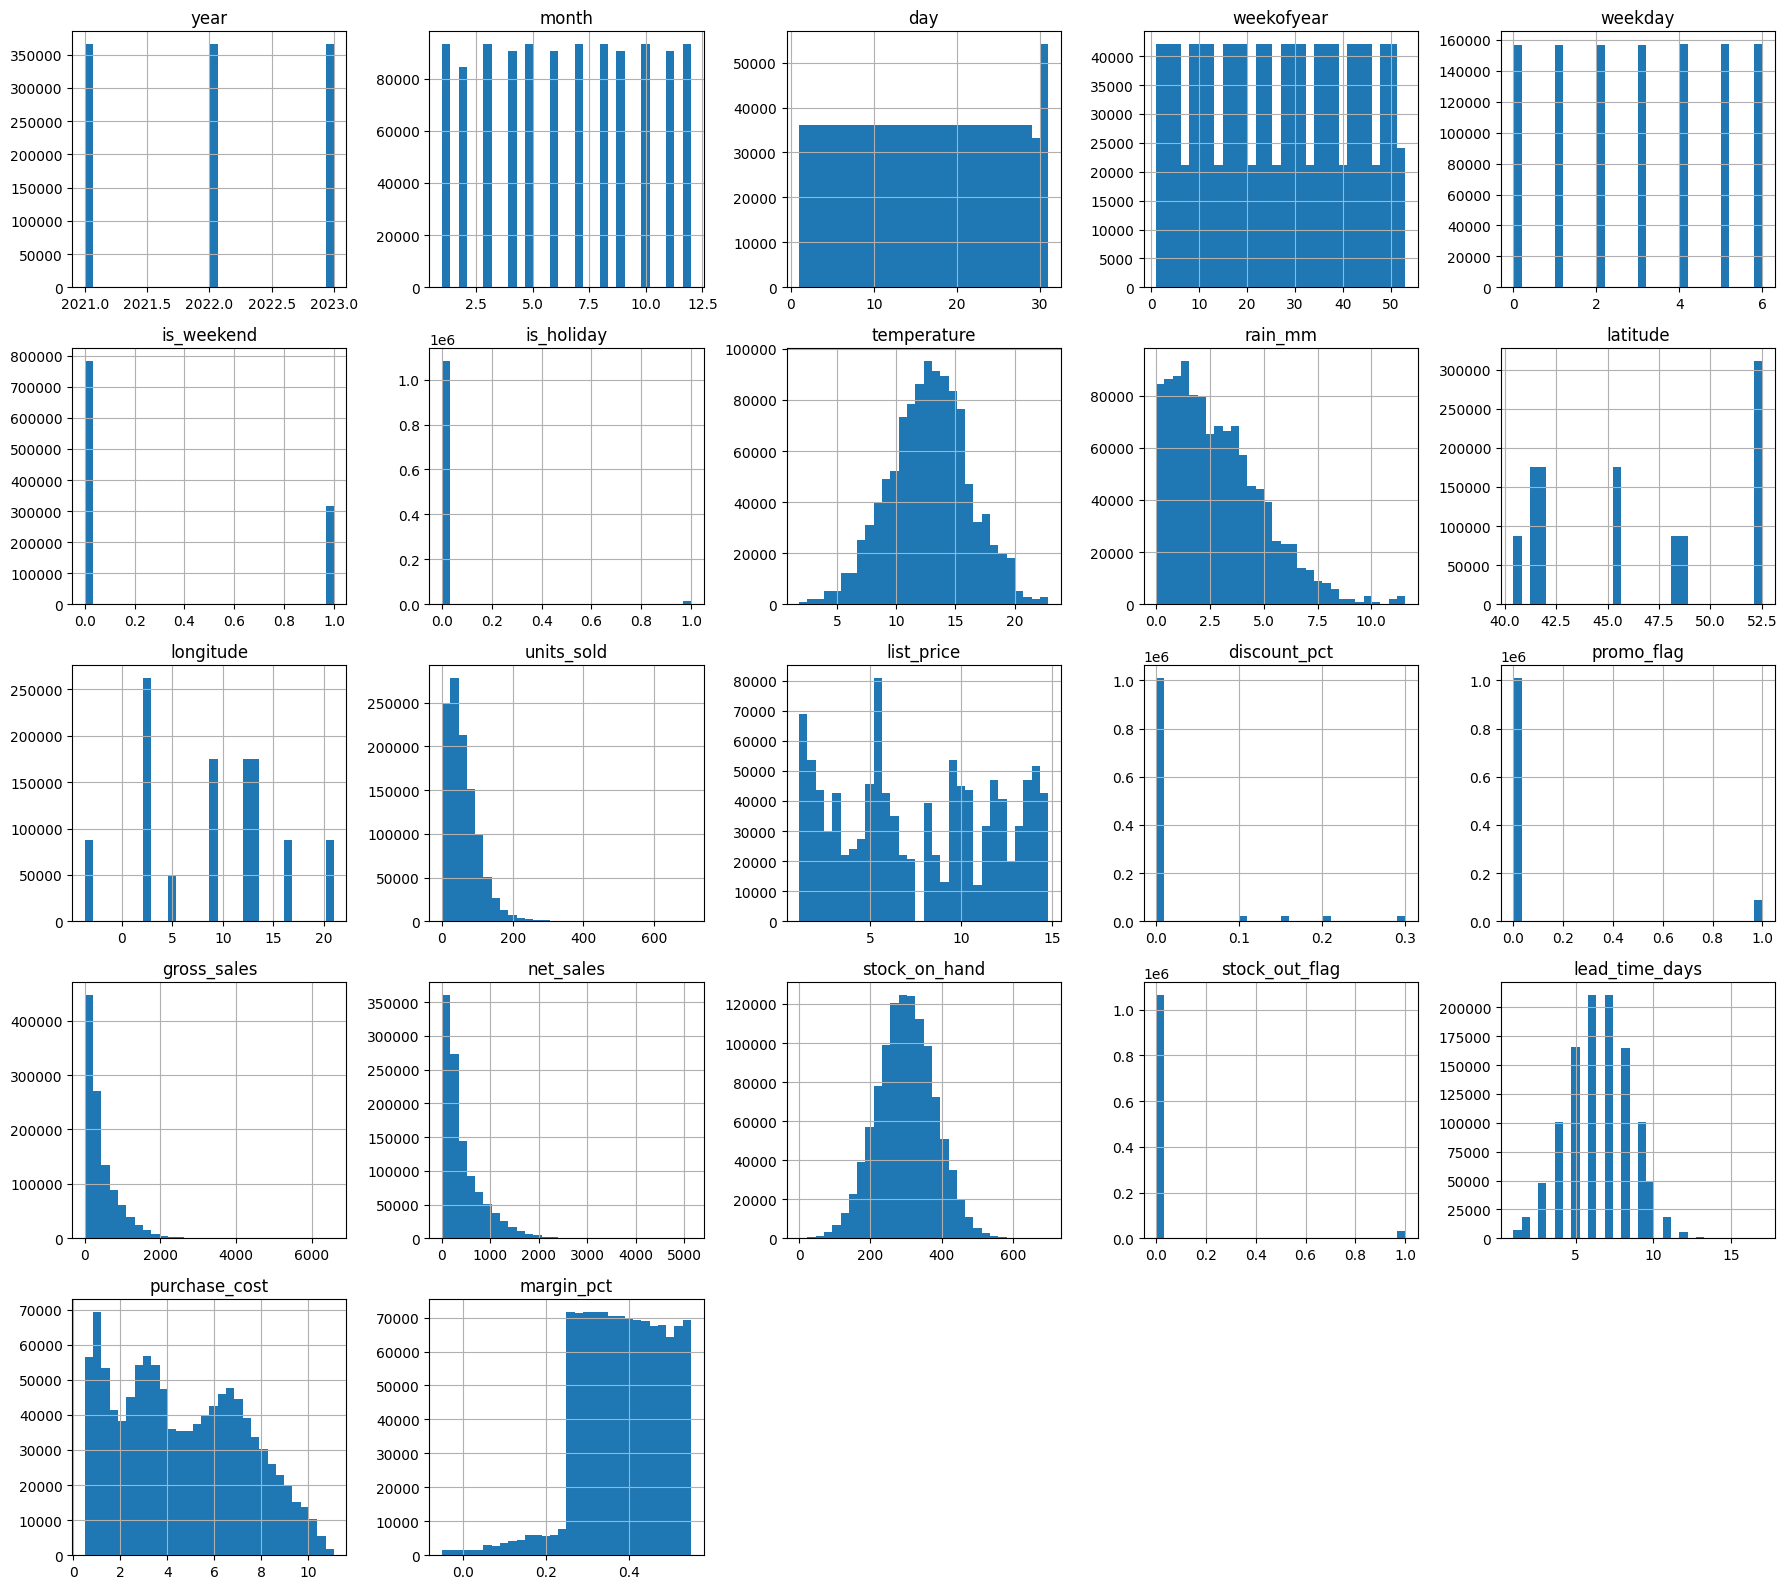

In [15]:
numerical = df.select_dtypes(include=np.number)

numerical.hist(

figsize=(18,16),

bins=30

)

plt.tight_layout()

plt.show()

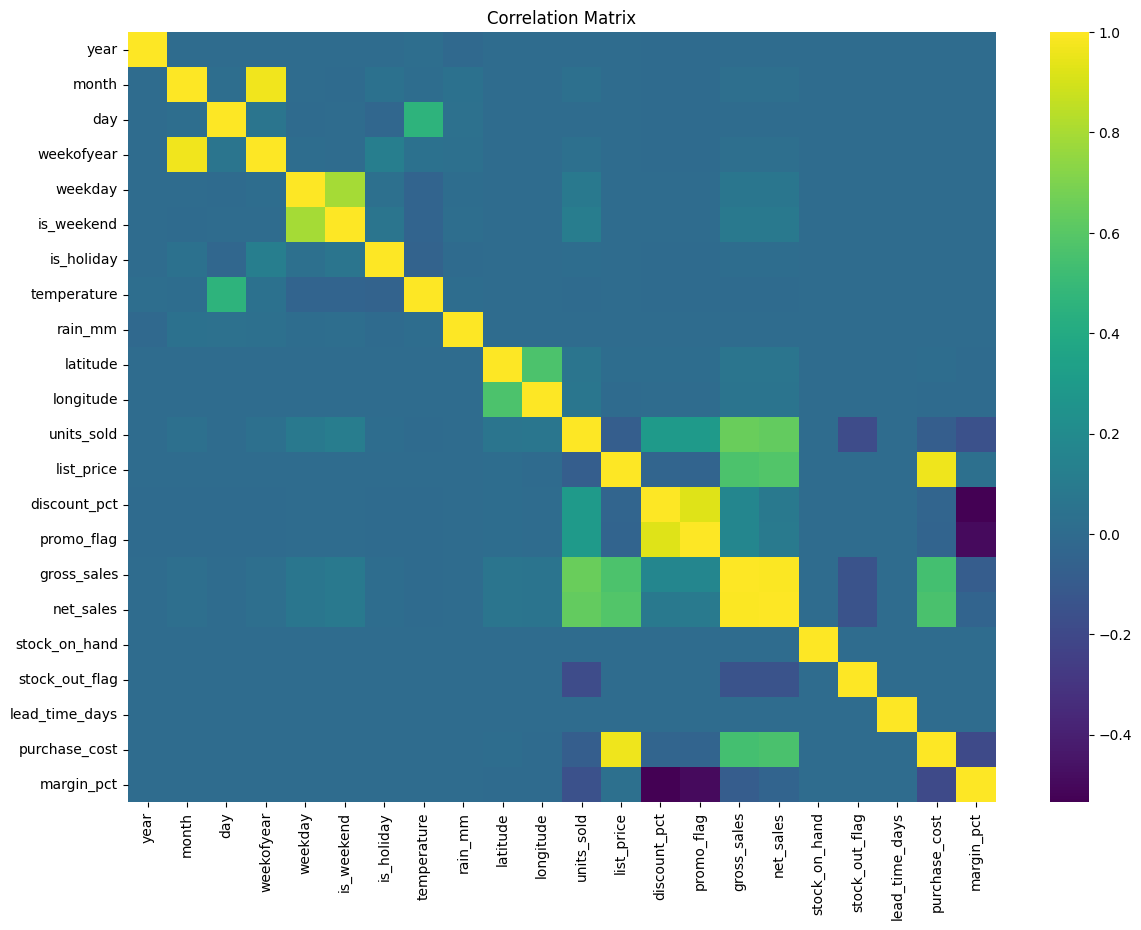

In [16]:
corr = numerical.corr()

plt.figure(figsize=(14,10))

import seaborn as sns

sns.heatmap(

corr,

annot=False,

cmap="viridis"

)

plt.title("Correlation Matrix")

plt.show()

In [17]:
quality = pd.DataFrame({

"Column":df.columns,

"Data Type":df.dtypes.values,

"Missing Values":df.isnull().sum().values,

"Unique Values":df.nunique().values

})

quality

,Column,Data Type,Missing Values,Unique Values
0,date,object,0,1095
1,year,int64,0,3
2,month,int64,0,12
3,day,int64,0,31
4,weekofyear,int64,0,53
5,weekday,int64,0,7
6,is_weekend,int64,0,2
7,is_holiday,int64,0,2
8,temperature,float64,0,710
9,rain_mm,float64,0,559


In [18]:
dictionary = pd.DataFrame({

"Column":df.columns,

"Description":[

"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
"",
""

]

})

dictionary

,Column,Description
0,date,
1,year,
2,month,
3,day,
4,weekofyear,
5,weekday,
6,is_weekend,
7,is_holiday,
8,temperature,
9,rain_mm,


## Initial Observations

The dataset contains over one million observations collected over three years.

The dataset includes sales, pricing, inventory, promotions, weather, geography, and supply chain variables.

The dataset appears suitable for demand forecasting.

Several columns require further inspection for missing values and possible outliers.

The dataset contains both categorical and numerical variables.

The next notebook will focus on SQL extraction and validation.

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/fmcg_sales_3years_1M_rows.csv")

print(df.shape)

(1100000, 33)
